#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Comparison of top predicted metabolites per model

In [3]:
path = 'drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results'

r2_mlp = pd.read_csv(f'{path}/r2_df_MLP.csv', index_col = 0)
r2_transfer_metabolic = pd.read_csv(f'{path}/r2_df_transfer_metabolic.csv', index_col = 0)
r2_transfer_tfs = pd.read_csv(f'{path}/r2_df_transfer_tfs.csv', index_col = 0)
r2_transfer_combination = pd.read_csv(f'{path}/r2_df_transfer_combination.csv', index_col = 0)
r2_transfer_unbiased = pd.read_csv(f'{path}/r2_df_transfer_unbiased.csv', index_col = 0)
r2_bulkrnabert = pd.read_csv(f'{path}/r2_df_BulkRNABert_nn.csv', index_col = 0)


spearman_mlp = pd.read_csv(f'{path}/spearman_df_MLP.csv', index_col = 0)
spearman_transfer_metabolic = pd.read_csv(f'{path}/spearman_df_transfer_metabolic.csv', index_col = 0)
spearman_transfer_tfs = pd.read_csv(f'{path}/spearman_df_transfer_tfs.csv', index_col = 0)
spearman_transfer_combination = pd.read_csv(f'{path}/spearman_df_transfer_combination.csv', index_col = 0)
spearman_transfer_unbiased = pd.read_csv(f'{path}/spearman_df_transfer_unbiased.csv', index_col = 0)
spearman_bulkrnabert = pd.read_csv(f'{path}/spearman_df_bulkrnabert_nn.csv', index_col = 0)

In [4]:
r2_mlp

,Metabolite,R2 Score
108,glycerate,0.953208
151,N-acetylalanine,0.952734
122,histidine,0.944427
201,threonine,0.943488
124,hypoxanthine,0.942377
...,...,...
117,guanosine 5'- monophosphate (5'-GMP),0.174030
93,gamma-glutamylglutamate,0.154320
0,"1,5-anhydroglucitol (1,5-AG)",0.151115
77,cytidine 5'-diphosphocholine,0.147863


In [5]:
r2_data = pd.concat([
                     r2_mlp.set_index('Metabolite').rename(columns = {'R2 Score' : 'MLP'}),
                     r2_transfer_metabolic.set_index('Metabolite').rename(columns = {'R2 Score' : 'transfer_metabolic'}),
                     r2_transfer_tfs.set_index('Metabolite').rename(columns = {'R2 Score' : 'transfer_tfs'}),
                     r2_transfer_combination.set_index('Metabolite').rename(columns = {'R2 Score' : 'transfer_combination'}),
                     r2_transfer_unbiased.set_index('Metabolite').rename(columns = {'R2 Score' : 'transfer_unbiased'}),
                     r2_bulkrnabert.set_index('Metabolite').rename(columns = {'R2 Score' : 'transfer_bulkrnabert'})
                     ], axis = 'columns')
r2_data

,MLP,transfer_metabolic,transfer_tfs,transfer_combination,transfer_unbiased,transfer_bulkrnabert
Metabolite,,,,,,
glycerate,0.953208,0.590083,0.649548,0.530309,0.287766,0.691716
N-acetylalanine,0.952734,0.485205,0.573149,0.478754,0.320133,0.677627
histidine,0.944427,0.533812,0.555551,0.489089,0.351809,0.628783
threonine,0.943488,0.561987,0.662896,0.574452,0.388092,0.526942
hypoxanthine,0.942377,0.474605,0.549997,0.462079,0.295667,0.669695
...,...,...,...,...,...,...
guanosine 5'- monophosphate (5'-GMP),0.174030,0.144888,0.031149,0.128455,-0.001814,-0.001832
gamma-glutamylglutamate,0.154320,-0.267193,0.033605,-0.172270,-0.143791,0.099359
"1,5-anhydroglucitol (1,5-AG)",0.151115,0.206781,0.104088,0.109391,-0.031303,0.096240


/tmp/ipython-input-1776093886.py:7: UserWarning: 
The palette list has fewer values (6) than needed (218) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(x="Model", y="R2", data=df_long, hue="Metabolite",  marker="o",  alpha=0.6, legend = False, size = 5, palette = palette)


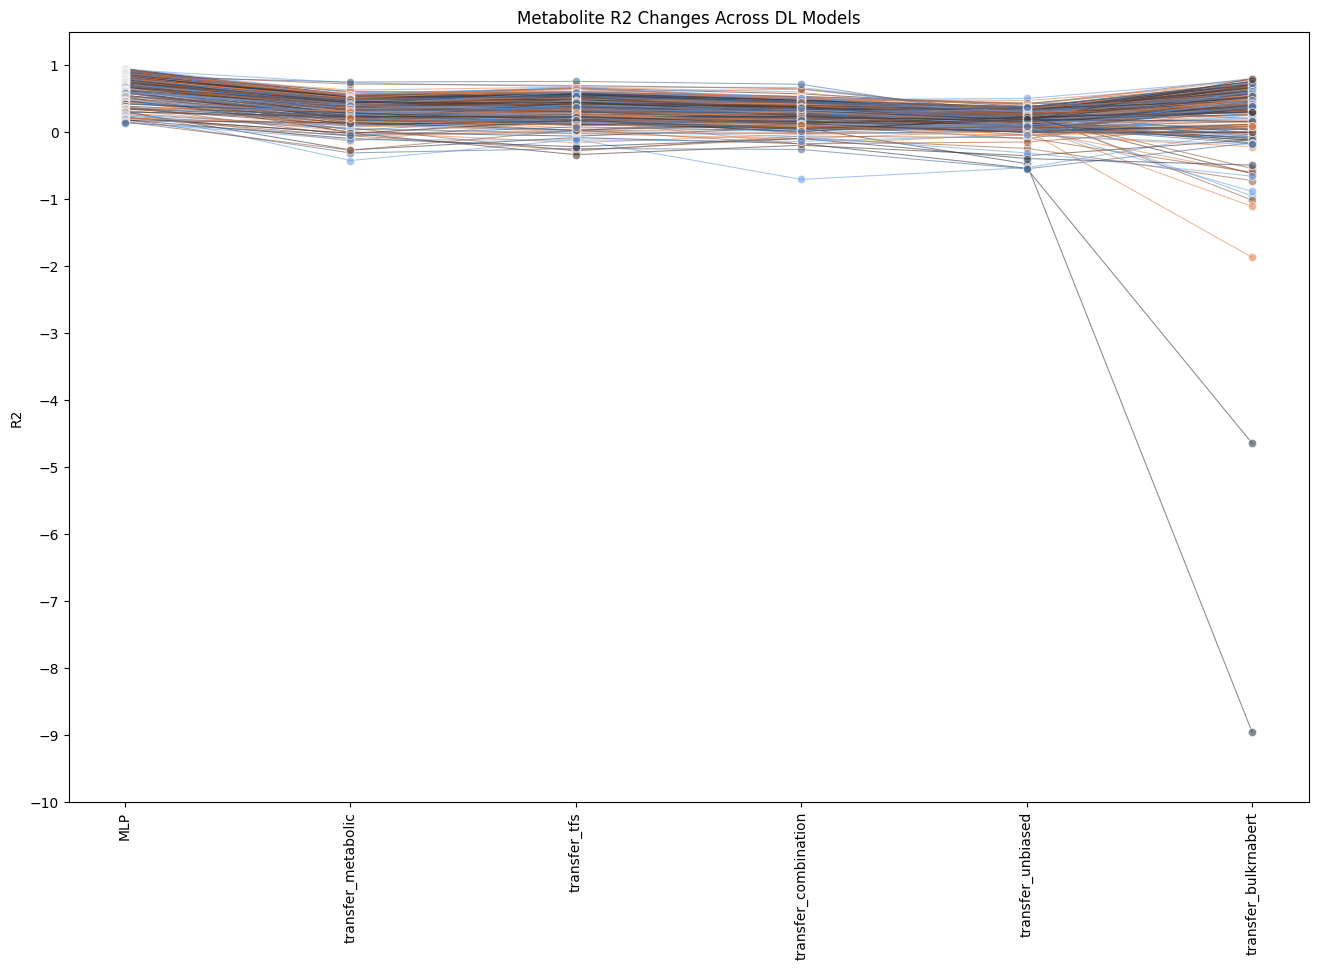

In [6]:
df_long = r2_data.reset_index().melt(id_vars="Metabolite", var_name="Model", value_name="R2")
df_long.rename(columns={"Metabolite": "Metabolite"}, inplace=True)

# Plot
plt.figure(figsize=(16, 10))
palette = sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=False)
sns.lineplot(x="Model", y="R2", data=df_long, hue="Metabolite",  marker="o",  alpha=0.6, legend = False, size = 5, palette = palette)
plt.ylim(-10, 1.5)
plt.yticks(np.arange(-10, 1.01, 1))
plt.xticks(rotation = 90)
plt.title("Metabolite R2 Changes Across DL Models")
plt.xlabel('')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/R2_changes_across_DL_models.svg', bbox_inches = 'tight')
plt.show()

In [7]:
spermans_data = pd.concat([
                            spearman_mlp.set_index('Metabolite').rename(columns = {'Spearman Coefficient' : 'MLP'}),
                            spearman_transfer_metabolic.set_index('Metabolite').rename(columns = {'Spearman Coefficient' : 'transfer_metabolic'}),
                            spearman_transfer_tfs.set_index('Metabolite').rename(columns = {'Spearman Coefficient' : 'transfer_tfs'}),
                            spearman_transfer_combination.set_index('Metabolite').rename(columns = {'Spearman Coefficient' : 'transfer_combination'}),
                            spearman_transfer_unbiased.set_index('Metabolite').rename(columns = {'Spearman Coefficient' : 'transfer_unbiased'}),
                            spearman_bulkrnabert.set_index('Metabolite').rename(columns = {'Spearman Coefficient' : 'transfer_bulkrnabert'}),
                            ], axis = 'columns')
spermans_data

,MLP,transfer_metabolic,transfer_tfs,transfer_combination,transfer_unbiased,transfer_bulkrnabert
Metabolite,,,,,,
hippurate,0.967046,0.858189,0.765672,0.810021,0.511250,0.875136
2-hydroxypalmitate,0.941480,0.785273,0.678685,0.791776,0.540644,0.825986
beta-alanine,0.937239,0.791564,0.750286,0.758132,0.735938,0.858641
phenylacetylglutamine,0.933804,0.845484,0.694815,0.804225,0.632680,0.789509
malate,0.933615,0.674137,0.729810,0.674700,0.639746,0.845525
...,...,...,...,...,...,...
cytidine 5'-diphosphocholine,0.428543,-0.026494,-0.182100,-0.297859,0.098763,0.403463
inositol 1-phosphate (I1P),0.388608,0.402603,0.187731,0.208228,0.214165,0.295025
erythritol,0.299701,0.308112,0.108712,0.230572,0.278990,0.323439


/tmp/ipython-input-1172142788.py:7: UserWarning: 
The palette list has fewer values (6) than needed (218) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(x="Model", y="Spearman's Coefficient", data=df_long, hue="Metabolite",  marker="o",  alpha=0.6, legend = False, size = 5, palette = palette)


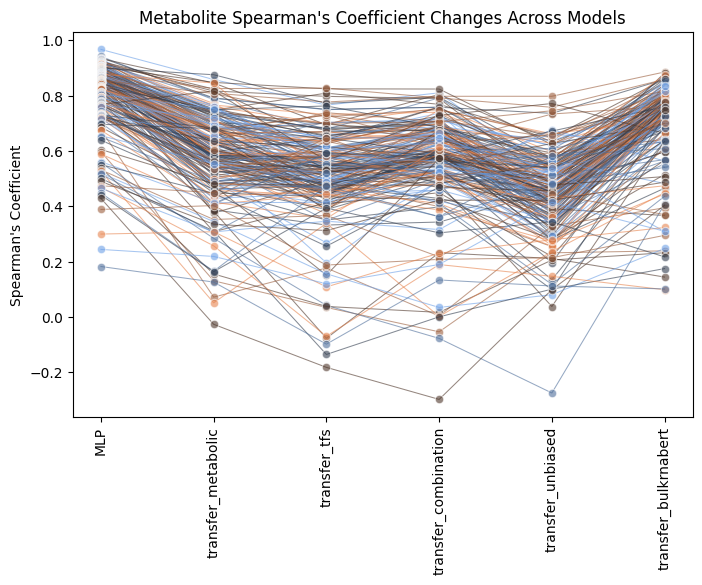

In [8]:
df_long = spermans_data.reset_index().melt(id_vars="Metabolite", var_name="Model", value_name="Spearman's Coefficient")
df_long.rename(columns={"Metabolite": "Metabolite"}, inplace=True)

# Plot
plt.figure(figsize=(8, 5))
palette = sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=False)
sns.lineplot(x="Model", y="Spearman's Coefficient", data=df_long, hue="Metabolite",  marker="o",  alpha=0.6, legend = False, size = 5, palette = palette)
plt.xticks(rotation = 90)
plt.title("Metabolite Spearman's Coefficient Changes Across Models")
plt.xlabel('')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Spearman_changes_across_DL_models.svg', bbox_inches = 'tight')
plt.show()

In [9]:
comparison_spearman = {
    'mlp' : 0.94,
    'transfer_metabolic' : 0.84,
    'transfer_tfs' : 0.85,
    'transfer_combination' : 0.83,
    'transfer_unbiased' : 0.79,
    'bulkrnabert' : 0.86
}

comparison_spearman = pd.DataFrame(list(comparison_spearman.items()), columns = ['Model', 'Spearman Coefficient']).set_index('Model')


comparison__val_loss_mse = {
   'mlp' : 0.0142,
   'transfer_metabolic' : 0.0305,
   'transfer_tfs' : 0.0662,
   'transfer_combination' : 0.0382,
   'transfer_unbiased' : 0.1157,
   'bulkrnabert' : 0.0388
}

comparison__val_loss_mse = pd.DataFrame(list(comparison__val_loss_mse.items()), columns = ['Model', 'MSE']).set_index('Model')

In [10]:
#Use negative MSE for better heatmap visuals

comparison_df = pd.concat([comparison_spearman, comparison__val_loss_mse*(-1)], axis = 'columns')
comparison_df

,Spearman Coefficient,MSE
Model,,
mlp,0.94,-0.0142
transfer_metabolic,0.84,-0.0305
transfer_tfs,0.85,-0.0662
transfer_combination,0.83,-0.0382
transfer_unbiased,0.79,-0.1157
bulkrnabert,0.86,-0.0388


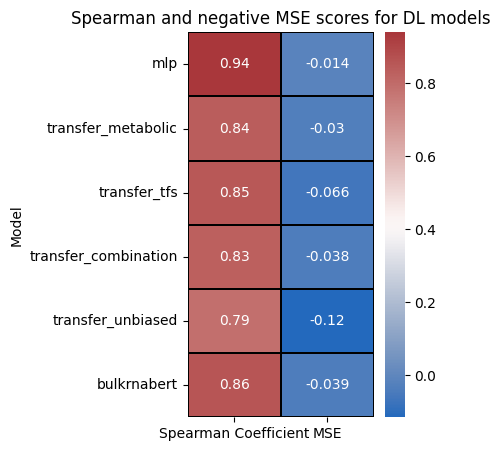

In [11]:
plt.figure(figsize = (3, 5))
sns.heatmap(comparison_df, cmap = sns.color_palette("vlag", as_cmap=True), linewidths = 0.05, linecolor='black', annot = True)
plt.title('Spearman and negative MSE scores for DL models')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/heatmap_spearman_neg_mse_dl.svg', bbox_inches = 'tight')